In [1]:
import os, sys
%pylab inline
plt.style.use('default')
import pandas as pd
from importlib import reload
spines_off = lambda ax: [ax.spines[side].set_visible(False) for side in ['top', 'right']]

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [4]:
import lucia_stats
import lucia_stats.src.paths as paths

In [6]:
import lucia_stats.src.data as lucia_data
reload(lucia_data)  
df, odour_cols = lucia_data.tidy_pandan(do_zscore=True)

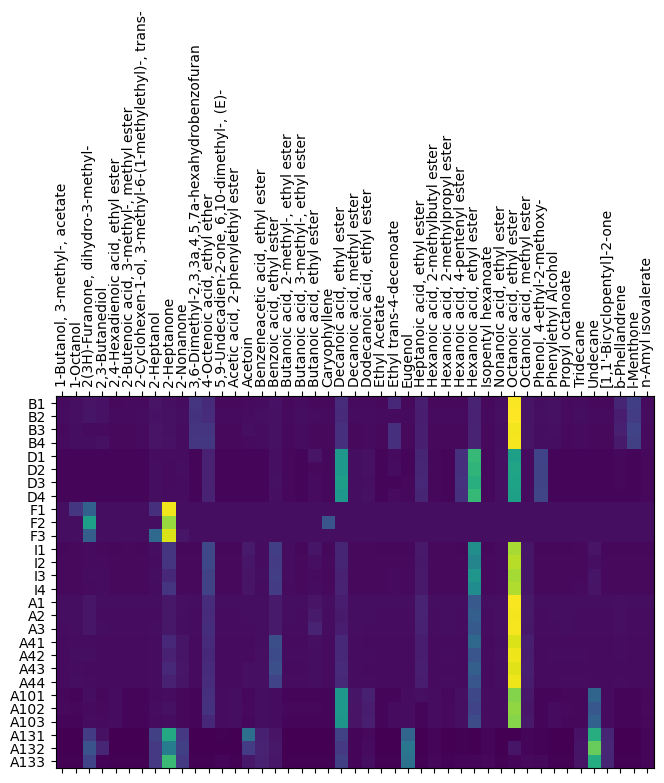

In [7]:
matshow(df[odour_cols].values)
gca().set_xticks(range(len(odour_cols)))
gca().set_xticklabels(odour_cols, rotation=90)
gca().set_yticks(range(len(df)))
gca().set_yticklabels([f"{row['Sample']}{row['Replicate']}" for _, row in df.iterrows()]);

In [10]:
import lucia_stats.src.erecta as erecta
import lucia_stats.src.common as common
reload(common)
reload(erecta)

<module 'lucia_stats.src.erecta' from '/Users/sinatootoonian/git/lucia-natural-odour-stats/lucia_stats/src/erecta.py'>

In [11]:
reload(lucia_data); 
reload(common)
reload(erecta)
A = erecta.Analysis(k=7)
results = A.fit_models()#results=results)

In [12]:
A.compute_sparsity()
A.compute_pc_var_overlap()
A.compute_confusion_matrices()
A.compute_p_values(n_rand=1000)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:15<00:00, 63.28it/s]


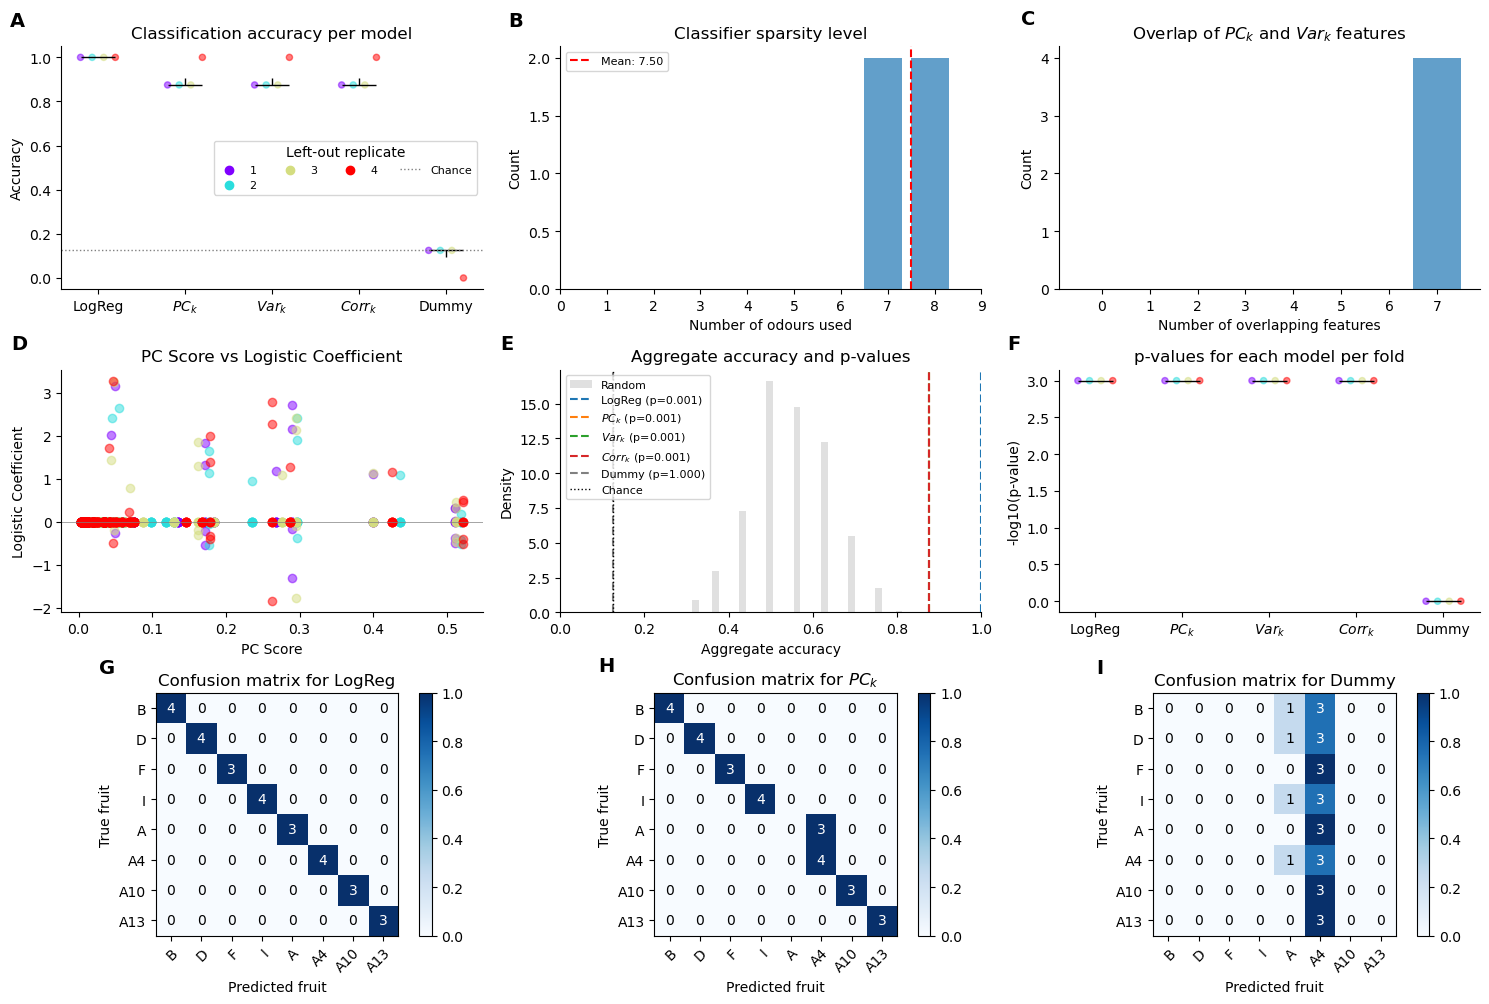

In [13]:
reload(erecta)
pr = erecta.PlotResults(A)
pr.plot_figure()
savefig(os.path.join(paths.figs_path, "erecta_all.pdf"), bbox_inches=None)

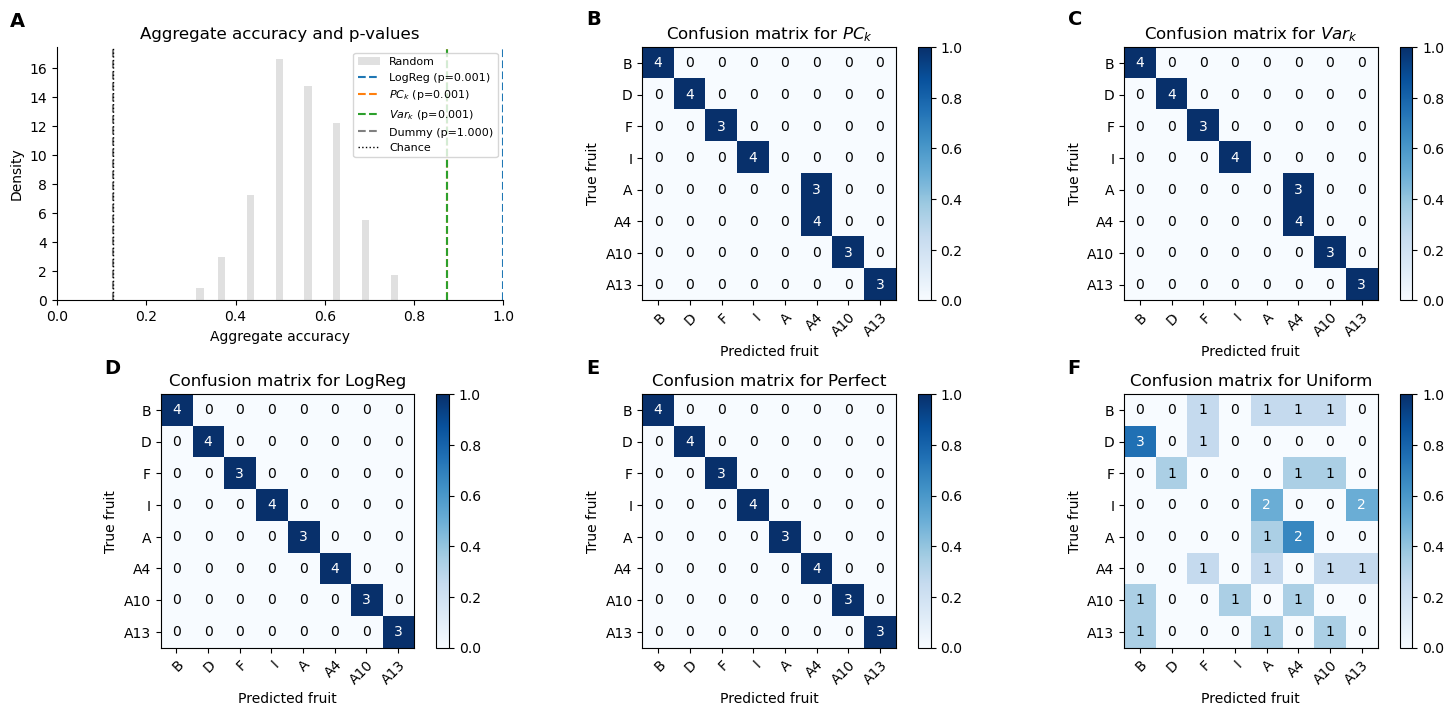

In [14]:
reload(common)
reload(erecta)
pr = erecta.PlotResults(A)
pr.plot_figure(panels=[
    (0, 0, "A", pr.plot_aggregate_p_values, ["logreg", "pc_k", "var_k", "dummy"]),
    (0, 1, "B", pr.plot_confusion_matrix, "pc_k"),
    (0, 2, "C", pr.plot_confusion_matrix, "var_k"),
    (1, 0, "D", pr.plot_confusion_matrix, "logreg"), 
    (1, 1, "E", pr.plot_confusion_matrix, "perfect"),
    (1, 2, "F", pr.plot_confusion_matrix, "uniform")
])
plt.savefig(os.path.join(paths.figs_path, "erecta.pdf"), bbox_inches=None)